In [63]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
dataset = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
(X_train, y_train), (X_test, y_test) = dataset

In [4]:
X_train.shape

(60000, 28, 28)

In [ ]:
y_train.shape

array([9, 0, 0, 3, 0], dtype=uint8)

In [6]:
classes = [
    'T-shirt/top',
	'Trouser',
	'Pullover',
	'Dress',
	'Coat',
	'Sandal',
	'Shirt',
	'Sneaker',
	'Bag',
	'Ankle boot'
]

In [18]:
def show_img(idx):
    plt.imshow(X_train[idx])
    print(classes[y_train[idx]])

Ankle boot


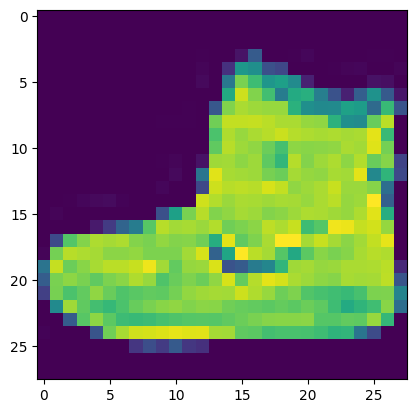

In [19]:
show_img(0)

Sandal


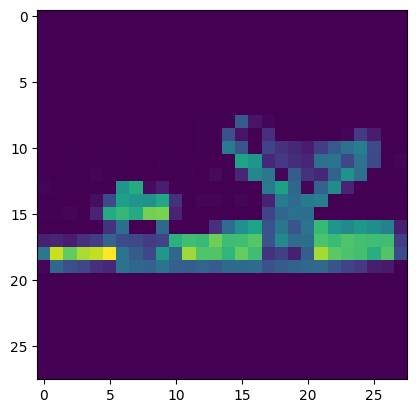

In [20]:
show_img(-1)

In [21]:
X_train_scaled = X_train / 255
X_test_scaled = X_test/ 255

In [31]:
### One hot encoding the labels

y_train_categorical = keras.utils.to_categorical(y_train, num_classes=10)
y_test_categorical = keras.utils.to_categorical(y_test, num_classes=10)

In [59]:
model = keras.Sequential([
        keras.layers.Flatten(input_shape=(28,28)),
        keras.layers.Dense(3000, activation='relu'),
        keras.layers.Dense(1000, activation='relu'),
        keras.layers.Dense(10, activation='sigmoid')
    ])

model.compile(
    optimizer='SGD',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train_scaled, y_train_categorical, epochs=1)


c:\Users\premt\OneDrive\Desktop\Programming\Portfolio\ml-algorithms\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.7884 - loss: 0.6445


In [66]:
prediction = model.predict(X_train_scaled)[0]
prediction

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step


array([0.04407834, 0.00438033, 0.02185458, 0.00593554, 0.04310745,
       0.9963034 , 0.05001696, 0.9989061 , 0.9705653 , 0.99995553],
      dtype=float32)

In [70]:
print(np.argmax(prediction))
classes[9]

9


'Ankle boot'

Ankle boot


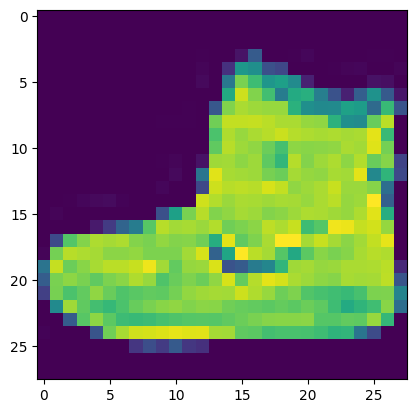

In [68]:
show_img(0)

In [52]:
def get_model():
    model = keras.Sequential([
        keras.layers.Flatten(input_shape=(28,28)),
        keras.layers.Dense(3000, activation='relu'),
        keras.layers.Dense(1000, activation='relu'),
        keras.layers.Dense(10, activation='sigmoid')
    ])

    model.compile(
        optimizer='SGD',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [53]:
%%timeit -n1 -r1

with tf.device('/CPU:0'):
    cpu_model = get_model()
    cpu_model.fit(X_train_scaled, y_train_categorical, epochs=1)

c:\Users\premt\OneDrive\Desktop\Programming\Portfolio\ml-algorithms\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.7894 - loss: 0.6431
18.2 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


T-shirt/top


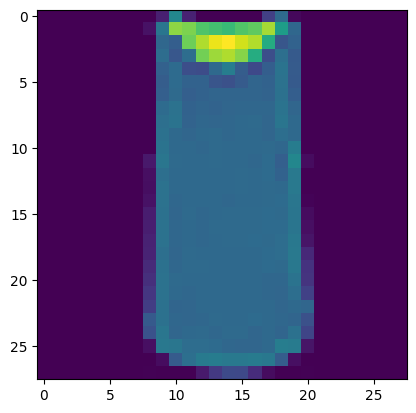

In [ ]:
show_img(2)

In [58]:
%%timeit -n1 -r1

with tf.device('/CPU:0'):
    cpu_model = get_model()
    cpu_model.fit(X_train_scaled, y_train_categorical, epochs=5)

Epoch 1/5


c:\Users\premt\OneDrive\Desktop\Programming\Portfolio\ml-algorithms\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.7925 - loss: 0.6333
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8432 - loss: 0.4522
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8567 - loss: 0.4101
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8644 - loss: 0.3867
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8718 - loss: 0.3653
1min 30s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
